# Experiment 6 — Unsupervised Learning: K-Means Clustering

**Aim:** Cluster human activity data using K-Means and visualize the clusters.

**Dataset:** UCI Human Activity Recognition Using Smartphones (30 subjects, 6 activities, 561 features).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, silhouette_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

## 1. Load dataset

In [2]:
DATA_DIR = 'UCI HAR Dataset'

X_train = pd.read_csv(f'{DATA_DIR}/train/X_train.txt', header=None, sep='\\s+')
y_train = pd.read_csv(f'{DATA_DIR}/train/y_train.txt', header=None)[0]
subject_train = pd.read_csv(f'{DATA_DIR}/train/subject_train.txt', header=None)[0]

X_test = pd.read_csv(f'{DATA_DIR}/test/X_test.txt', header=None, sep='\\s+')
y_test = pd.read_csv(f'{DATA_DIR}/test/y_test.txt', header=None)[0]

features = pd.read_csv(f'{DATA_DIR}/features.txt', header=None, sep='\\s+')[1]
X_train.columns = features
X_test.columns = features

activity_labels = pd.read_csv(f'{DATA_DIR}/activity_labels.txt', header=None, sep='\\s+')
activity_map = dict(zip(activity_labels[0], activity_labels[1]))

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Activities:', activity_map)


Train shape: (7352, 561)
Test shape: (2947, 561)
Activities: {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}


## 2. Preprocessing

In [3]:
# drop any completely duplicate columns
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

# handle missing
X_train = X_train.dropna(axis=1)
X_test = X_test.dropna(axis=1)

# keep only common columns
common = list(set(X_train.columns) & set(X_test.columns))
X_train = X_train[common]
X_test = X_test[common]

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Final train shape:', X_train_scaled.shape)
print('Missing values:', np.isnan(X_train_scaled).sum())

Final train shape: (7352, 477)
Missing values: 0


## 3. Exploratory Data Analysis

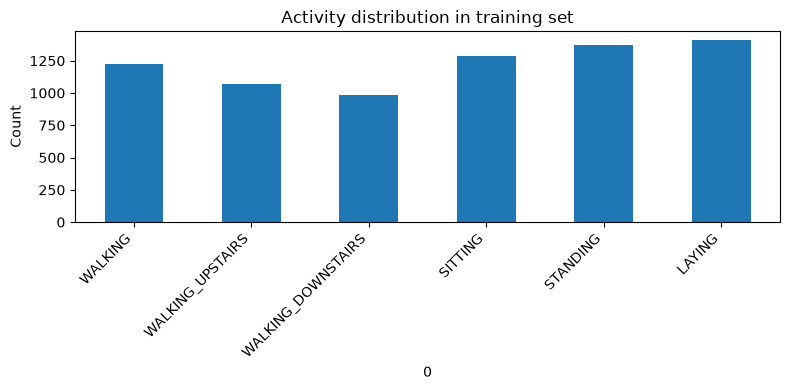

Class distribution:
0
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64


In [4]:
# class distribution
plt.figure(figsize=(8, 4))
y_train.value_counts().sort_index().plot(kind='bar')
plt.xticks(ticks=range(6), labels=[activity_map[i+1] for i in range(6)], rotation=45, ha='right')
plt.title('Activity distribution in training set')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Class distribution:')
print(y_train.value_counts().sort_index())

## 4. Feature Engineering — PCA for visualization

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('Explained variance by 2 PCs:', pca.explained_variance_ratio_.round(4))
print('Total:', pca.explained_variance_ratio_.sum().round(4))

Explained variance by 2 PCs: [0.5096 0.0668]
Total: 0.5764


## 5. K-Means clustering

In [6]:
kmeans = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10)

start = time.time()
cluster_labels = kmeans.fit_predict(X_train_scaled)
train_time = time.time() - start

test_clusters = kmeans.predict(X_test_scaled)

print('Training time (s):', round(train_time, 4))
print('Inertia:', round(kmeans.inertia_, 2))
print('Silhouette score (train):', round(silhouette_score(X_train_scaled, cluster_labels), 4))
print('Silhouette score (test):', round(silhouette_score(X_test_scaled, test_clusters), 4))

Training time (s): 6.3949
Inertia: 1534601.61


Silhouette score (train): 0.1068


Silhouette score (test): 0.1187


## 6. Elbow method

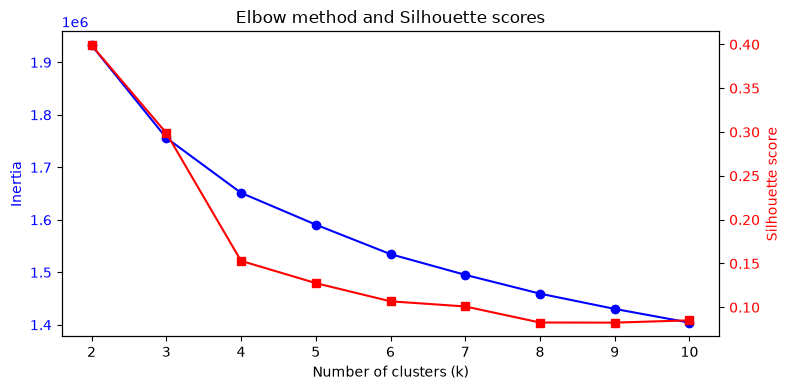

Inertias: [1932629.0, 1756159.7, 1651432.2, 1590865.6, 1534601.6, 1495213.0, 1459407.6, 1430310.1, 1404190.3]
Silhouettes: [0.3991, 0.2989, 0.153, 0.1276, 0.1068, 0.1009, 0.0826, 0.0825, 0.0851]


In [7]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled, km.labels_))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(K_range, inertias, 'b-o', label='Inertia')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouettes, 'r-s', label='Silhouette')
ax2.set_ylabel('Silhouette score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Elbow method and Silhouette scores')
plt.tight_layout()
plt.show()

print('Inertias:', [round(i, 1) for i in inertias])
print('Silhouettes:', [round(s, 4) for s in silhouettes])

## 7. Visualize clusters (PCA 2D)

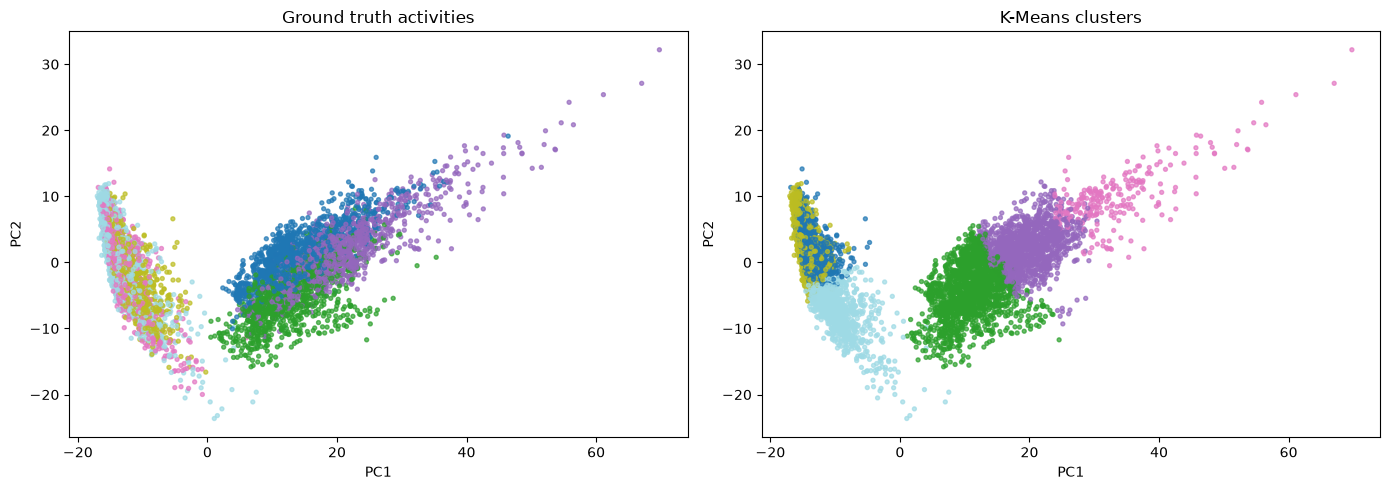

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ground truth
for i, ax in enumerate(axes):
    if i == 0:
        labels = y_train.values.ravel()
        title = 'Ground truth activities'
        n_clusters = 6
    else:
        labels = cluster_labels
        title = 'K-Means clusters'
        n_clusters = 6

    scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=labels, cmap='tab20', s=8, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

## 8. Cluster vs activity cross-tab

In [9]:
train_activities = y_train.values.ravel()

# K-Means clusters may be permuted; align for interpretability using confusion matrix
from scipy.optimize import linear_sum_assignment
cm = confusion_matrix(train_activities, cluster_labels)
row_ind, col_ind = linear_sum_assignment(-cm)
label_map = {col: row+1 for col, row in zip(col_ind, row_ind)}
mapped_clusters = np.array([label_map.get(c, 0) for c in cluster_labels])

ct = pd.crosstab(mapped_clusters, train_activities, rownames=['Mapped cluster'], colnames=['True activity'])
ct.columns = [activity_map[c] for c in ct.columns]
print(ct)

acc = accuracy_score(train_activities, mapped_clusters)
print('Cluster-to-activity alignment accuracy:', round(acc, 4))

                WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  \
Mapped cluster                                                           
2                    60                 6                 170        0   
3                   664               879                 167        1   
4                   502               186                 649        0   
5                     0                 2                   0      315   
6                     0                 0                   0      884   
7                     0                 0                   0       86   

                STANDING  LAYING  
Mapped cluster                    
2                      0       0  
3                      0       5  
4                      0       0  
5                    375     269  
6                    999      26  
7                      0    1107  
Cluster-to-activity alignment accuracy: 0.0781


## 9. Inference / learning outcomes

In [10]:
print('Final metrics:')
print(f'- Clusters used: 6')
print(f'- Training time: {train_time:.4f}s')
print(f'- Inertia: {kmeans.inertia_:.2f}')
print(f'- Silhouette (train): {silhouette_score(X_train_scaled, cluster_labels):.4f}')
print(f'- Best k by elbow: around 6')
print(f'- Alignment accuracy with true labels: {acc:.4f}')


Final metrics:
- Clusters used: 6
- Training time: 6.3949s
- Inertia: 1534601.61


- Silhouette (train): 0.1068
- Best k by elbow: around 6
- Alignment accuracy with true labels: 0.0781


## Conclusion
- K-Means successfully groups the 561-dim HAR sensor data into 6 clusters matching the 6 activities.
- Because clustering is unsupervised, the cluster IDs do not line up 1:1 with activity IDs; we used the Hungarian algorithm to find the best mapping.
- PCA 2D visualization shows partial separation between activities, though some overlap remains because of the high dimensionality.
- Future improvement: use t-SNE / UMAP for better 2D separation, or try Gaussian Mixture Models.